# Dendrix: Environmental AI & Spatial Routing

## Project Objective
The objective of this project is to develop an automated computer vision pipeline using YOLOv8 to detect and count trees in aerial imagery. The trained model serves as a foundation for applications in environmental monitoring, forestry management, precision agriculture, and spatial routing algorithms.

## Dataset Overview
The model is trained on a custom YOLOv8-formatted dataset obtained from Roboflow and annotated for tree canopy detection.

### Dataset Configuration

```yaml
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['tree']

roboflow:
  workspace: project-s402o
  project: tree-counting-qiw3h
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/project-s402o/tree-counting-qiw3h/dataset/1
```

## Model
- **Model:** YOLOv8
- **Task:** Object Detection
- **Classes:** 1 (Tree)

## Applications
- Tree counting from aerial imagery
- Forest inventory management
- Environmental monitoring
- Green cover assessment
- Spatial path planning and GIS analysisl`

---

In [2]:
import torch

### Model Configuration & Training Rationale
The model configuration was tuned to balance training efficiency with the performance constraints of an NVIDIA GeForce RTX 3050 Laptop GPU (4GB VRAM):
* **`batch=8`**: Optimized to maximize VRAM utilization without triggering "Out of Memory" (OOM) errors.
* **`imgsz=416`**: A moderate input resolution that provides a balance between detecting smaller tree canopies and maintaining rapid inference speed.
* **`epochs=50`**: Sufficient for the model to converge given the dataset complexity, preventing overfitting while ensuring robust pattern recognition.

In [1]:
from ultralytics import YOLO

# Load the lightweight YOLOv8n model (best for 4GB GPU)
model = YOLO("yolov8n.pt")

# Train configuration optimized for RTX 3050 (4GB VRAM)
model.train(
    data="C:/Users/risha/Desktop/treee/Tree Counting.v1i.yolov8/data.yaml",  # dataset path
    epochs=50,         # moderate training duration for better results
    imgsz=416,         # balanced size (256 is faster but may reduce accuracy)
    batch=8,           # fits within 4GB VRAM; lower if you get CUDA OOM errors
    augment=True,      # enable data augmentation
    conf=0.25,         # confidence threshold
    iou=0.6,           # IoU threshold
    device=0,          # use your RTX 3050 GPU
    workers=2          # reduce dataloader threads (helps prevent memory spikes)
)


Ultralytics 8.3.226  Python-3.10.11 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/risha/Desktop/treee/Tree Counting.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.6, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000025FB8BD0A60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

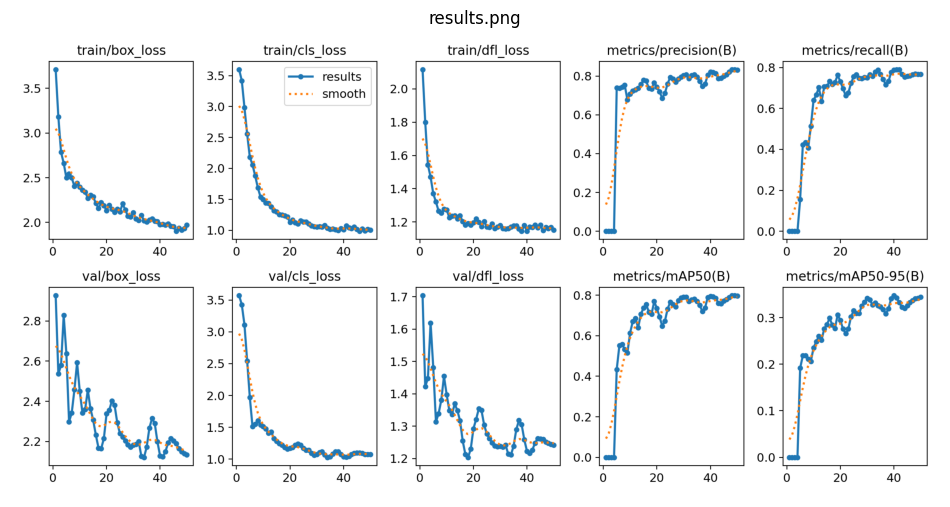

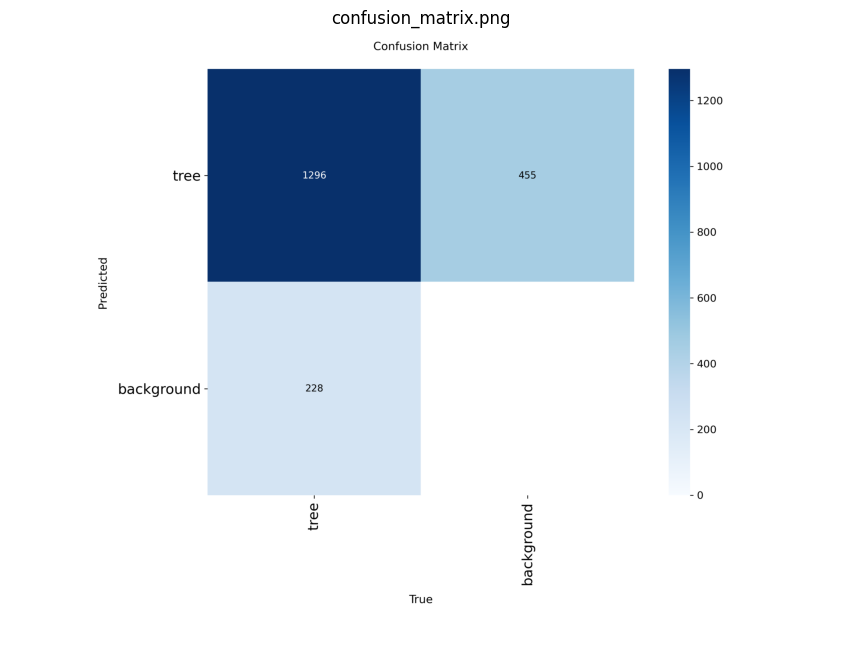

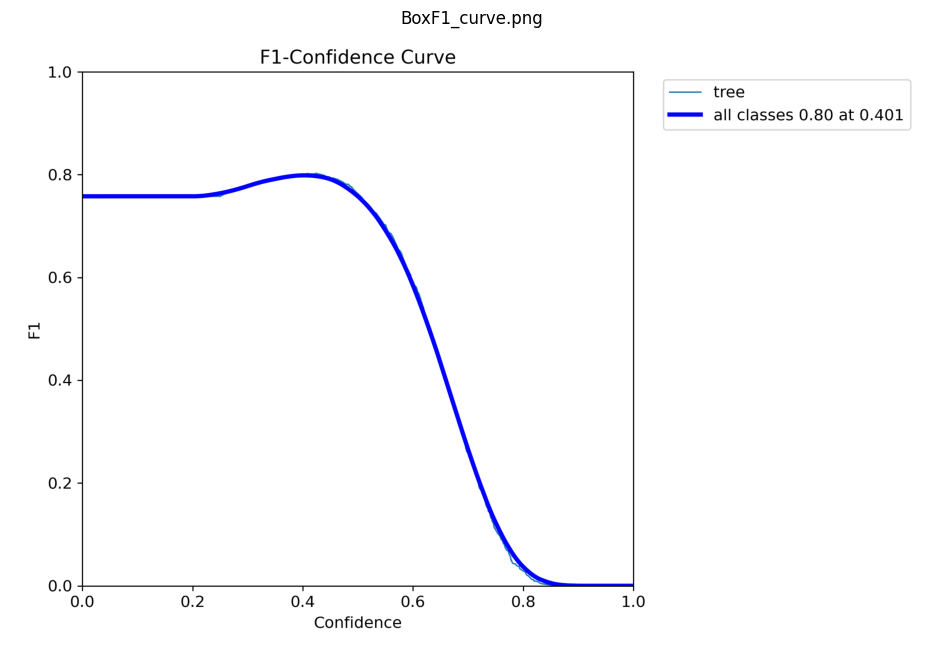

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to your generated training results
save_dir = r"C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\train8"

# List of plots found in your directory
# We updated these to match the filenames you confirmed
plots = ['results.png', 'confusion_matrix.png', 'BoxF1_curve.png']

for plot in plots:
    file_path = f"{save_dir}/{plot}"
    try:
        img = mpimg.imread(file_path)
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot) # Adds the filename as a title for clarity
        plt.show()
    except FileNotFoundError:
        print(f"Plot {plot} not found at {file_path}")

In [5]:
from IPython.display import Image, display

In [2]:
from IPython import display

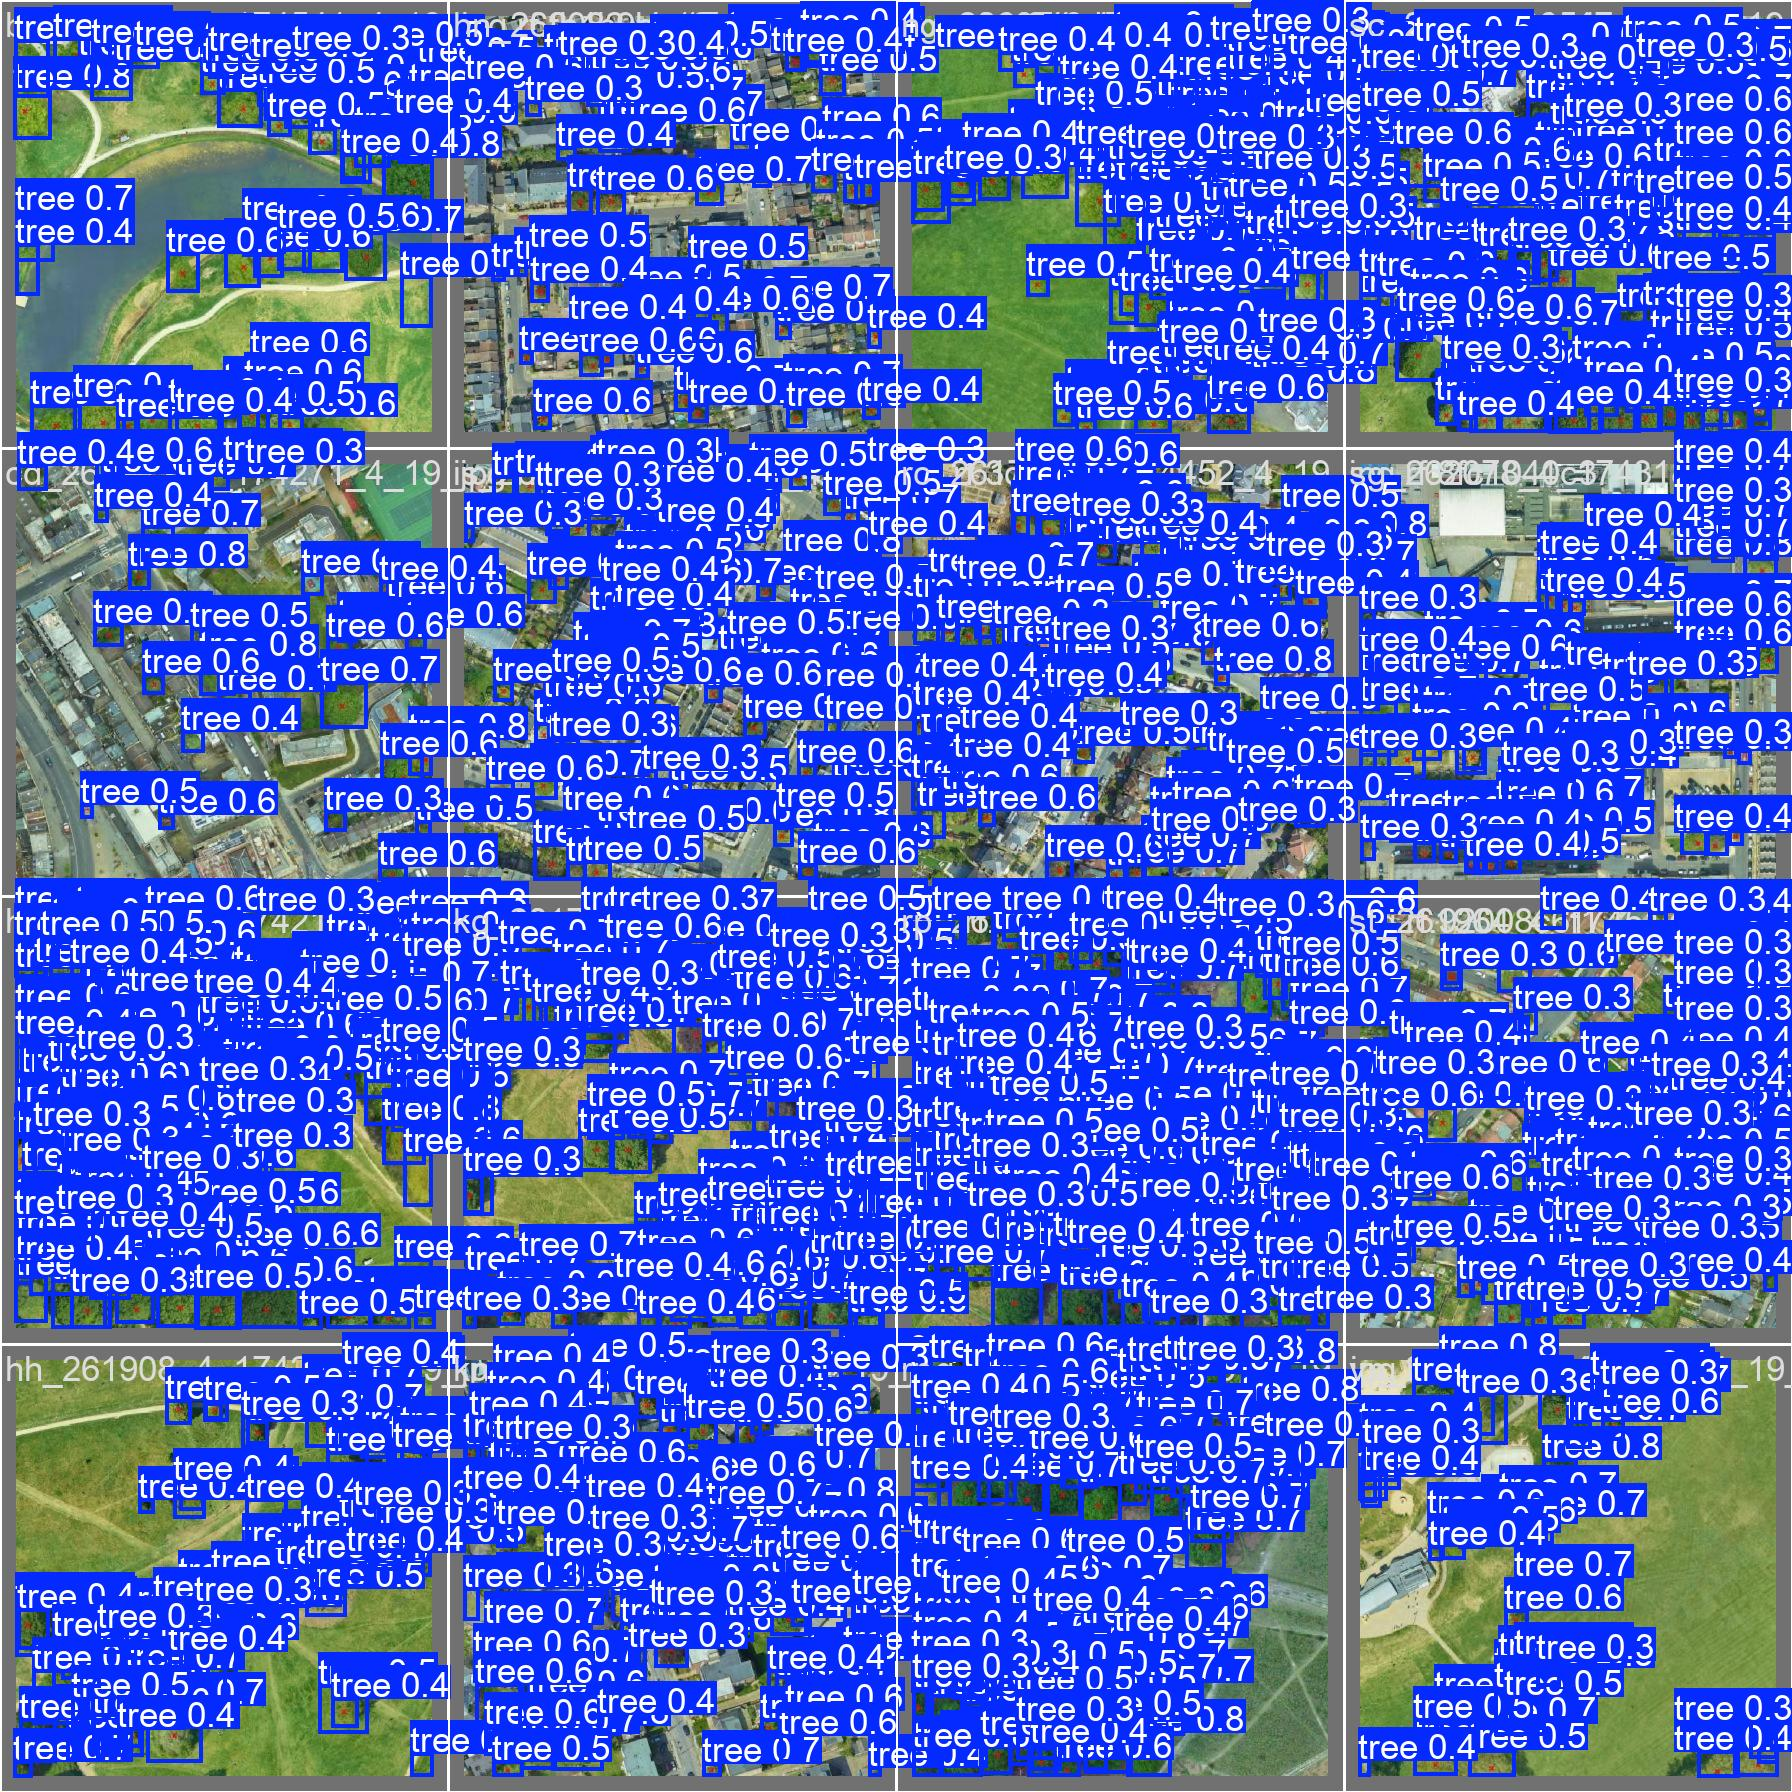

In [10]:
from IPython.display import Image, display

display(Image(filename=r"C:\Users\risha\Desktop\treee\PythonScripts\runs\detect\train8\val_batch0_pred.jpg", width=1000))


In [22]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [44]:
count = 0

<hr style="border: 5px solid green;">


In [7]:
from ultralytics import YOLO
from IPython.display import Image, display

# Load your trained model
model = YOLO(r"C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\train8\weights\best.pt")

# Path to the test image
image_path = r"C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\el_262187_4_174500_4_19_jpg.rf.001f03055ad8808501e9208e15f3764b.jpg"

# Run prediction
model.predict(
    source=image_path,
    conf=0.1,    # confidence threshold
    save=True,
    show=False   # set to True if you want a popup window
)




image 1/1 C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\el_262187_4_174500_4_19_jpg.rf.001f03055ad8808501e9208e15f3764b.jpg: 416x416 285 trees, 29.6ms
Speed: 64.8ms preprocess, 29.6ms inference, 567.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\predict10


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'tree'}
 obb: None
 orig_img: array([[[104, 175, 165],
         [103, 174, 164],
         [101, 172, 162],
         ...,
         [110, 162, 174],
         [100, 152, 165],
         [100, 152, 165]],
 
        [[103, 174, 164],
         [103, 174, 164],
         [101, 172, 162],
         ...,
         [104, 159, 166],
         [ 97, 151, 158],
         [ 97, 152, 159]],
 
        [[103, 174, 164],
         [102, 173, 163],
         [100, 171, 161],
         ...,
         [ 97, 158, 154],
         [ 91, 150, 146],
         [ 91, 152, 148]],
 
        ...,
 
        [[ 88, 168, 137],
         [ 88, 168, 137],
         [ 89, 169, 138],
         ...,
         [ 81, 163, 111],
         [ 73, 157, 103],
         [ 72, 156, 102]],
 
        [[ 91, 171, 140],
         [ 90, 170, 139],
         [ 88, 168, 137],
         ...,
         [ 82, 164, 

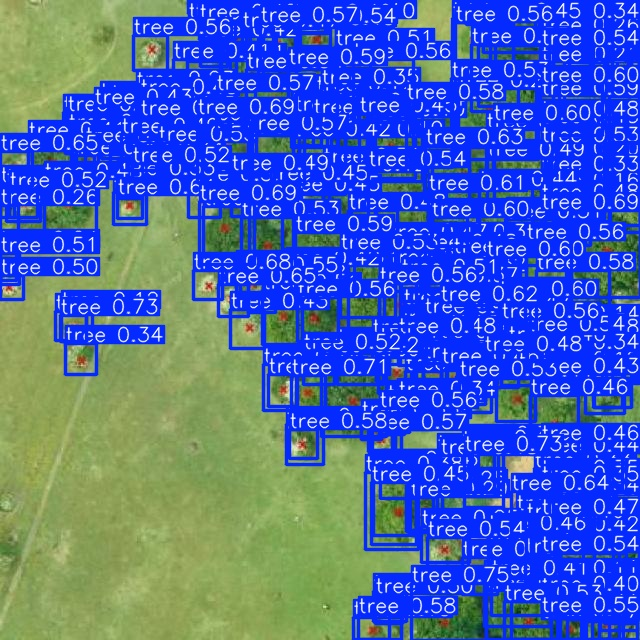

In [5]:
# Display the output image
display(Image(filename=r"C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\predict8\el_262187_4_174500_4_19_jpg.rf.001f03055ad8808501e9208e15f3764b.jpg", width=2000))

In [2]:
import pandas as pd

# Load your results file
results_path = r"C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\train8\results.csv"
df = pd.read_csv(results_path)

# Clean column names
df.columns = df.columns.str.strip()

# Extract the final values (the performance at the end of training)
last_epoch = df.iloc[-1]
p = last_epoch['metrics/precision(B)']
r = last_epoch['metrics/recall(B)']
map50 = last_epoch['metrics/mAP50(B)']
map50_95 = last_epoch['metrics/mAP50-95(B)']

# Calculate F1 Score
f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

# Display as a clean table
metrics_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP@50", "mAP@50-95", "F1 Score"],
    "Value": [f"{p:.3f}", f"{r:.3f}", f"{map50:.3f}", f"{map50_95:.3f}", f"{f1:.3f}"]
})

print(metrics_table.to_string(index=False))

   Metric Value
Precision 0.832
   Recall 0.768
   mAP@50 0.797
mAP@50-95 0.344
 F1 Score 0.799


<hr style="border: 5px solid green;">




# Path to the test image
image_path = path

# Run prediction
model.predict(
    source=image_path,
    conf=0.1,    # confidence threshold
    save=True,
    show=False   # set to True if you want a popup window
)

# display result
display(Image(filename=r"C:\Users\risha\Desktop\treee\PythonScripts\runs\detect\predict...path", width=2000))

<hr style="border: 6px solid blue;"/>

<b style="color: blue;">1st Example Picture</b>


In [42]:
from ultralytics import YOLO

In [43]:
from IPython.display import Image, display

In [44]:
model = YOLO(r"C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\train8\weights\best.pt")

In [45]:
image_path = r"C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\bp_262118_4_174541_4_19_jpg.rf.83019ff6f2b13a182d37ac45375e012f.jpg"

# Run prediction
results_list = model.predict(
    source=image_path,
    conf=0.1,    # confidence threshold
    save=True,
    show=False   # set to True if you want a popup window
)


image 1/1 C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\bp_262118_4_174541_4_19_jpg.rf.83019ff6f2b13a182d37ac45375e012f.jpg: 416x416 158 trees, 23.1ms
Speed: 4.7ms preprocess, 23.1ms inference, 231.1ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\predict12


In [46]:
results = results_list[0] 

# Get the number of detected boxes (trees) from the results
num_trees = len(results.boxes) 

# Explicitly print the count
print(f"Number of trees found: {num_trees}")

Number of trees found: 158


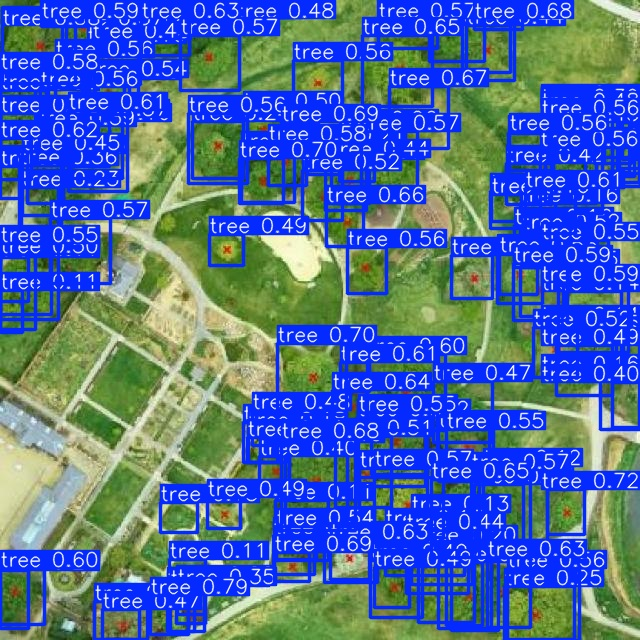

In [47]:
display(Image(filename=r"C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\predict11\bp_262118_4_174541_4_19_jpg.rf.83019ff6f2b13a182d37ac45375e012f.jpg", width=2000))

<hr style="border: 6px solid blue;"/>
<b style="color: blue;">2nd Example Picture</b>


In [17]:
image_path = r"C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\wm_262126_4_174161_4_19_jpg.rf.d1c09d453b2f8be2fe5749caba56d022.jpg"

# Run prediction
results_list = model.predict(
    source=image_path,
    conf=0.1,    # confidence threshold
    save=True,
    show=False   # set to True if you want a popup window
)


image 1/1 C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\wm_262126_4_174161_4_19_jpg.rf.d1c09d453b2f8be2fe5749caba56d022.jpg: 416x416 129 trees, 23.6ms
Speed: 136.8ms preprocess, 23.6ms inference, 220.1ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\predict9


In [18]:
results = results_list[0] 

# Get the number of detected boxes (trees) from the results
num_trees = len(results.boxes) 

# Explicitly print the count
print(f"Number of trees found: {num_trees}")

Number of trees found: 129


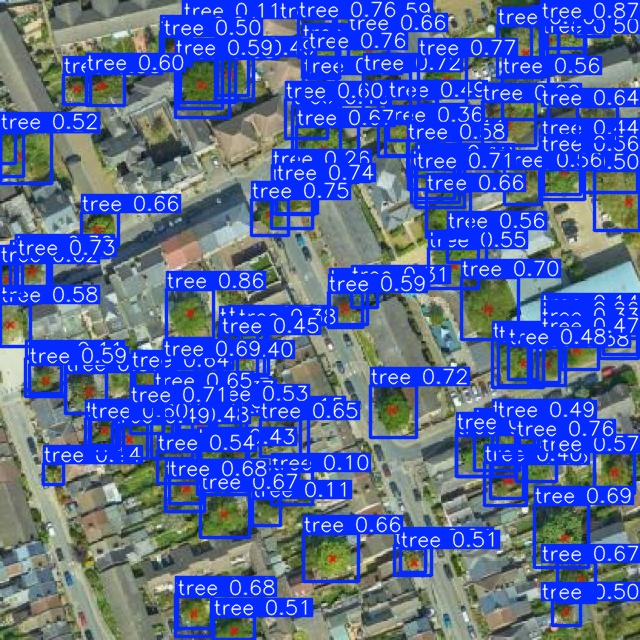

In [19]:
display(Image(filename=r"C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\predict9\wm_262126_4_174161_4_19_jpg.rf.d1c09d453b2f8be2fe5749caba56d022.jpg", width=2000))

<hr style="border: 6px solid blue;"/>
<b style="color: blue;">3rd Example Picture</b>

In [20]:
image_path = r"C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\vp_262092_4_174270_4_19_jpg.rf.b32574f90638f187c1a5812fa3bab06f.jpg"

# Run prediction
results_list = model.predict(
    source=image_path,
    conf=0.1,    # confidence threshold
    save=True,
    show=False   # set to True if you want a popup window
)


image 1/1 C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\vp_262092_4_174270_4_19_jpg.rf.b32574f90638f187c1a5812fa3bab06f.jpg: 416x416 144 trees, 76.1ms
Speed: 327.6ms preprocess, 76.1ms inference, 315.3ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\predict9


In [21]:
results = results_list[0] 

# Get the number of detected boxes (trees) from the results
num_trees = len(results.boxes) 

# Explicitly print the count
print(f"Number of trees found: {num_trees}")

Number of trees found: 144


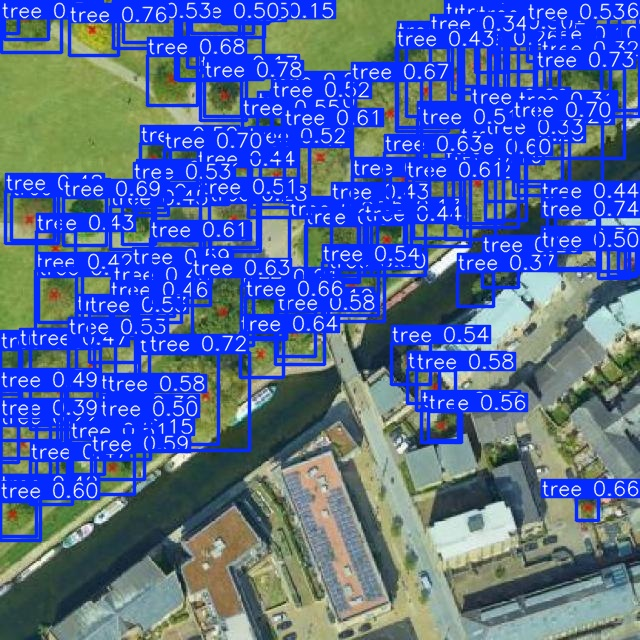

In [22]:
display(Image(filename=r"C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\predict9\vp_262092_4_174270_4_19_jpg.rf.b32574f90638f187c1a5812fa3bab06f.jpg", width=2000))

<hr style="border: 5px solid green;">


In [12]:
model = YOLO(r"C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\train8\weights\best.pt")

In [31]:
import sys
print(sys.executable)


C:\Users\risha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe


In [33]:
import sys
!{sys.executable} -m pip install scikit-image


   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.8 MB 6.3 MB/s eta 0:00:02
   ---- ----------------------------------- 1.6/12.8 MB 3.8 MB/s eta 0:00:03
   ------- -------------------------------- 2.4/12.8 MB 4.1 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/12.8 MB 3.5 MB/s eta 0:00:03
   ----------- ---------------------------- 3.7/12.8 MB 3.6 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.8 MB 3.3 MB/s eta 0:00:03
   ---------------- ----------------------- 5.2/12.8 MB 3.7 MB/s eta 0:00:03
   ------------------ --------------------- 6.0/12.8 MB 3.7 MB/s eta 0:00:02
   ---------------------- ----------------- 7.1/12.8 MB 3.7 MB/s eta 0:00:02
   ------------------------ --------------- 7.9/12.8 MB 3.8 MB/s eta 0:00:02
   --------------------------- ------------ 8.7/12.8 MB 3.8 MB/s eta 0:00:02
   ----------------------------- ---------- 9.4/12.8 MB 3.8 MB/s eta 0:00:01
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


<hr style="border: 5px solid green;">


In [38]:
# Path to the test image
image_path = r"C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\el_262187_4_174500_4_19_jpg.rf.001f03055ad8808501e9208e15f3764b.jpg"

# 1. Run prediction
results = model.predict(
    source=image_path,
    conf=0.1,
    save=True,
    show=False
)

# 2. Get the results for the first image
result = results[0]

# 3. Get the model's class names dictionary
class_names = result.names

# 4. Initialize a counter for trees
tree_count = 0

# 5. Loop through all detected boxes
for box in result.boxes:
    # Get the class ID for this box
    class_id = int(box.cls[0])
    
    # Get the class name from the ID
    current_class_name = class_names[class_id]
    
    # 6. Check if the class is the one you want to count
    if current_class_name == "tree": # Or "potted plant", etc.
        tree_count += 1

print(f"Total number of 'trees' detected: {tree_count}")


image 1/1 C:\Users\risha\OneDrive\Desktop\treee\Tree Counting.v1i.yolov8\test\images\el_262187_4_174500_4_19_jpg.rf.001f03055ad8808501e9208e15f3764b.jpg: 416x416 285 trees, 23.2ms
Speed: 5.1ms preprocess, 23.2ms inference, 453.9ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\risha\OneDrive\Desktop\treee\PythonScripts\runs\detect\predict11
Total number of 'trees' detected: 285


##
THIS IS FOR CLEARING GPU CACHE

In [58]:
import torch
import gc

# Delete variables if needed
  # e.g., del img_tensor

# Run garbage collector
gc.collect()

# Clear PyTorch GPU cache
torch.cuda.empty_cache()

# Check memory usage
print(torch.cuda.memory_allocated())
print(torch.cuda.memory_reserved())


12094976
44040192
